![image info](https://raw.githubusercontent.com/albahnsen/MIAD_ML_and_NLP/main/images/banner_1.png)

# Proyecto 2 - Clasificación de género de películas

El propósito de este proyecto es que puedan poner en práctica, en sus respectivos grupos de trabajo, sus conocimientos sobre técnicas de preprocesamiento, modelos predictivos de NLP, y la disponibilización de modelos. Para su desarrollo tengan en cuenta las instrucciones dadas en la "Guía del proyecto 2: Clasificación de género de películas"

**Entrega**: La entrega del proyecto deberán realizarla durante la semana 8. Sin embargo, es importante que avancen en la semana 7 en el modelado del problema y en parte del informe, tal y como se les indicó en la guía.

Para hacer la entrega, deberán adjuntar el informe autocontenido en PDF a la actividad de entrega del proyecto que encontrarán en la semana 8, y subir el archivo de predicciones a la [competencia de Kaggle](https://www.kaggle.com/t/29c44fce98c747f2a1dfdaf29d4c4965).

## Datos para la predicción de género en películas

![image info](https://raw.githubusercontent.com/albahnsen/MIAD_ML_and_NLP/main/images/moviegenre.png)

En este proyecto se usará un conjunto de datos de géneros de películas. Cada observación contiene el título de una película, su año de lanzamiento, la sinopsis o plot de la película (resumen de la trama) y los géneros a los que pertenece (una película puede pertenercer a más de un género). Por ejemplo:
- Título: 'How to Be a Serial Killer'
- Plot: 'A serial killer decides to teach the secrets of his satisfying career to a video store clerk.'
- Generos: 'Comedy', 'Crime', 'Horror'

La idea es que usen estos datos para predecir la probabilidad de que una película pertenezca, dada la sinopsis, a cada uno de los géneros.

Agradecemos al profesor Fabio González, Ph.D. y a su alumno John Arevalo por proporcionar este conjunto de datos. Ver https://arxiv.org/abs/1702.01992

## Ejemplo predicción conjunto de test para envío a Kaggle
En esta sección encontrarán el formato en el que deben guardar los resultados de la predicción para que puedan subirlos a la competencia en Kaggle.

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Importación librerías
import pandas as pd
import os
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.multiclass import OneVsRestClassifier
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import r2_score, roc_auc_score
from sklearn.model_selection import train_test_split

In [4]:
# Carga de datos de archivo .csv
dataTraining = pd.read_csv('https://github.com/albahnsen/MIAD_ML_and_NLP/raw/main/datasets/dataTraining.zip', encoding='UTF-8', index_col=0)
dataTesting = pd.read_csv('https://github.com/albahnsen/MIAD_ML_and_NLP/raw/main/datasets/dataTesting.zip', encoding='UTF-8', index_col=0)

In [10]:
# Visualización datos de entrenamiento
dataTraining.head()

,year,title,plot,genres,rating
3107,2003,Most,most is the story of a single father who takes...,"['Short', 'Drama']",8.0
900,2008,How to Be a Serial Killer,a serial killer decides to teach the secrets o...,"['Comedy', 'Crime', 'Horror']",5.6
6724,1941,A Woman's Face,"in sweden , a female blackmailer with a disfi...","['Drama', 'Film-Noir', 'Thriller']",7.2
4704,1954,Executive Suite,"in a friday afternoon in new york , the presi...",['Drama'],7.4
2582,1990,Narrow Margin,"in los angeles , the editor of a publishing h...","['Action', 'Crime', 'Thriller']",6.6


In [11]:
# Visualización datos de test
dataTesting.head()

,year,title,plot
1,1999,Message in a Bottle,"who meets by fate , shall be sealed by fate ...."
4,1978,Midnight Express,"the true story of billy hayes , an american c..."
5,1996,Primal Fear,martin vail left the chicago da ' s office to ...
6,1950,Crisis,husband and wife americans dr . eugene and mr...
7,1959,The Tingler,the coroner and scientist dr . warren chapin ...


In [ ]:
# # Definición de variables predictoras (X)
# vect = CountVectorizer(max_features=1000)
# X_dtm = vect.fit_transform(dataTraining['plot'])
# X_dtm.shape

(7895, 1000)

In [ ]:
# # Definición de variable de interés (y)
# dataTraining['genres'] = dataTraining['genres'].map(lambda x: eval(x))
# le = MultiLabelBinarizer()
# y_genres = le.fit_transform(dataTraining['genres'])

In [ ]:
# # Separación de variables predictoras (X) y variable de interés (y) en set de entrenamiento y test usandola función train_test_split
# X_train, X_test, y_train_genres, y_test_genres = train_test_split(X_dtm, y_genres, test_size=0.33, random_state=42)

In [ ]:
# # Definición y entrenamiento
# clf = OneVsRestClassifier(RandomForestClassifier(n_jobs=-1, n_estimators=100, max_depth=10, random_state=42))
# clf.fit(X_train, y_train_genres)

OneVsRestClassifier(estimator=RandomForestClassifier(max_depth=10, n_jobs=-1,
                                                     random_state=42))

In [ ]:
# # Predicción del modelo de clasificación
# y_pred_genres = clf.predict_proba(X_test)

# # Impresión del desempeño del modelo
# roc_auc_score(y_test_genres, y_pred_genres, average='macro')

0.7812262183677007

In [ ]:
# # transformación variables predictoras X del conjunto de test
# X_test_dtm = vect.transform(dataTesting['plot'])

# cols = ['p_Action', 'p_Adventure', 'p_Animation', 'p_Biography', 'p_Comedy', 'p_Crime', 'p_Documentary', 'p_Drama', 'p_Family',
#         'p_Fantasy', 'p_Film-Noir', 'p_History', 'p_Horror', 'p_Music', 'p_Musical', 'p_Mystery', 'p_News', 'p_Romance',
#         'p_Sci-Fi', 'p_Short', 'p_Sport', 'p_Thriller', 'p_War', 'p_Western']

# # Predicción del conjunto de test
# y_pred_test_genres = clf.predict_proba(X_test_dtm)

In [ ]:
# # Guardar predicciones en formato exigido en la competencia de kaggle
# res = pd.DataFrame(y_pred_test_genres, index=dataTesting.index, columns=cols)
# res.to_csv('pred_genres_text_RF.csv', index_label='ID')
# res.head()

,p_Action,p_Adventure,p_Animation,p_Biography,p_Comedy,p_Crime,p_Documentary,p_Drama,p_Family,p_Fantasy,...,p_Musical,p_Mystery,p_News,p_Romance,p_Sci-Fi,p_Short,p_Sport,p_Thriller,p_War,p_Western
1,0.143030,0.101960,0.024454,0.029938,0.354552,0.138830,0.030787,0.490140,0.073159,0.101339,...,0.025069,0.063208,0.000000,0.362818,0.056648,0.008970,0.017522,0.202605,0.033989,0.018117
4,0.122624,0.085786,0.024213,0.084795,0.370949,0.216657,0.080359,0.515684,0.062976,0.067019,...,0.024734,0.060935,0.000477,0.149703,0.058190,0.014248,0.020099,0.204794,0.030438,0.018506
5,0.151364,0.110284,0.013762,0.075334,0.304837,0.448736,0.021010,0.611544,0.081741,0.169121,...,0.044538,0.261372,0.000000,0.335987,0.128505,0.001016,0.048658,0.423242,0.052693,0.025351
6,0.154448,0.125772,0.020991,0.064124,0.340779,0.140892,0.009133,0.632038,0.068287,0.063631,...,0.131074,0.088418,0.000000,0.197224,0.132208,0.001432,0.039743,0.269385,0.077607,0.017862
7,0.175143,0.210069,0.035476,0.032505,0.313850,0.243150,0.021793,0.427885,0.079781,0.143879,...,0.023859,0.090359,0.000048,0.205117,0.241663,0.002634,0.018403,0.259465,0.021569,0.017585


## **EDA**

In [23]:
# 1. Exploración inicial de los datos

# 1.1. Forma de los datos
print('dataTraining shape:', dataTraining.shape)
print('dataTesting shape:', dataTesting.shape)

dataTraining shape: (7895, 5)
dataTesting shape: (3383, 3)


In [22]:
# 1.2. Valores faltantes o nulos
print('dataTraining null values:')
print(dataTraining.isnull().sum())
print('dataTesting null values:')
print(dataTesting.isnull().sum())

dataTraining null values:
year      0
title     0
plot      0
genres    0
rating    0
dtype: int64
dataTesting null values:
year     0
title    0
plot     0
dtype: int64


In [27]:
# 1.3. Tipos de datos
print('dataTraining data types:')  
print(dataTraining.dtypes)
print('dataTesting data types:')
print(dataTesting.dtypes)

dataTraining data types:
year        int64
title      object
plot       object
genres     object
rating    float64
dtype: object
dataTesting data types:
year      int64
title    object
plot     object
dtype: object


In [28]:
dataTraining['genres'] = dataTraining['genres'].map(lambda x: eval(x))

In [45]:
generos = pd.DataFrame(dataTraining['genres'].explode().value_counts())
generos

,genres
Drama,3965
Comedy,3046
Thriller,2024
Romance,1892
Crime,1447
Action,1303
Adventure,1024
Horror,954
Mystery,759
Sci-Fi,723


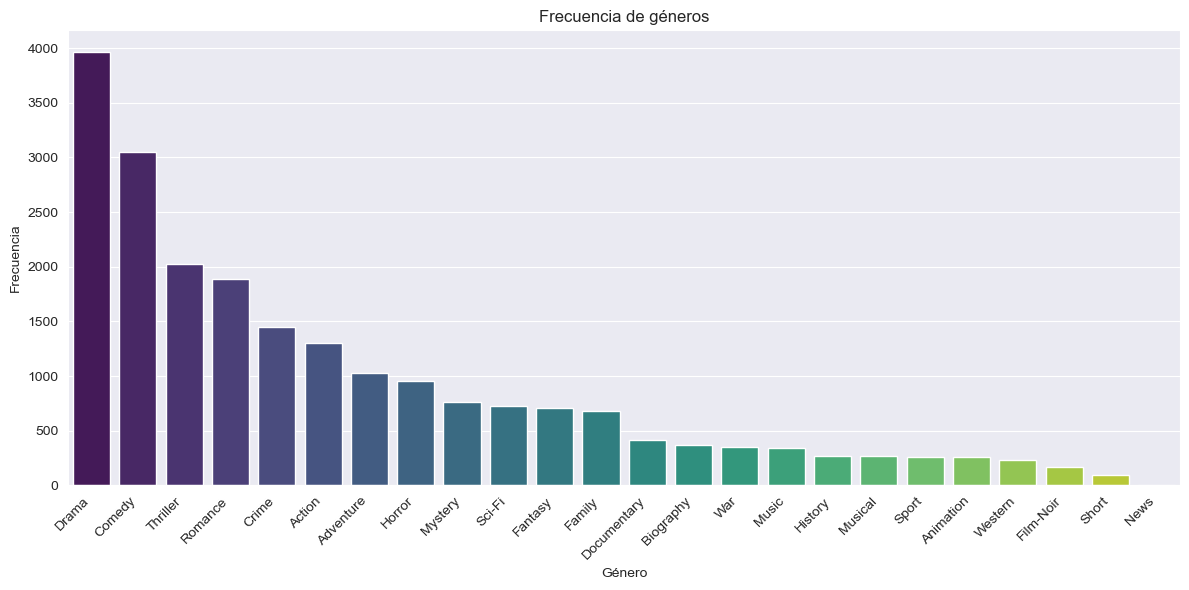

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_style('darkgrid')

plt.figure(figsize = (12, 6))
sns.barplot(data = generos, x = generos.index, y = generos['genres'], palette = 'viridis')
plt.xticks(rotation = 45, ha = 'right')
plt.title('Frecuencia de géneros')
plt.xlabel('Género')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()

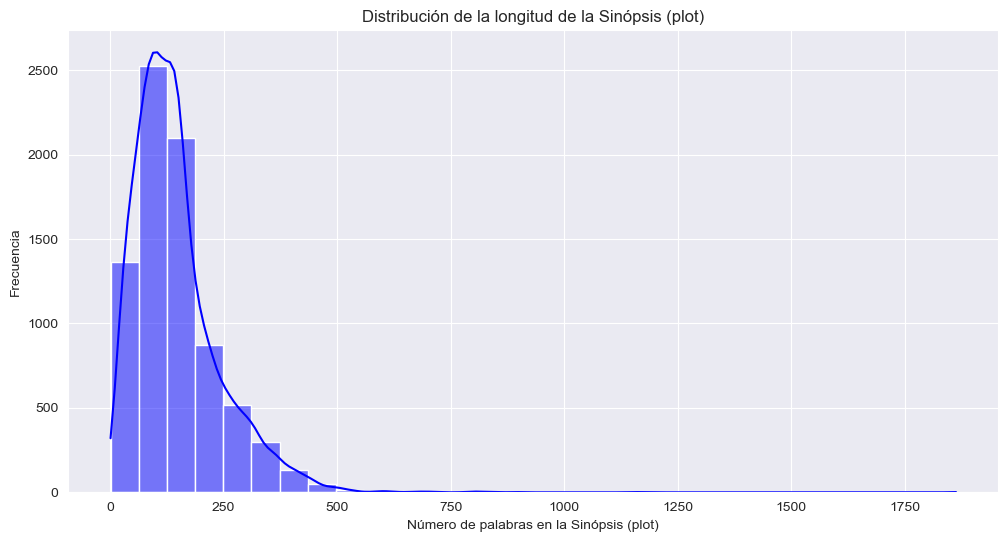

In [ ]:
dataTraining['plot_length'] = dataTraining['plot'].apply(lambda x: len(x.split()))
plt.figure(figsize = (12, 6))
sns.histplot(data = dataTraining, x = 'plot_length', bins = 30, kde = True, color = 'blue')
plt.title('Distribución de la longitud de la Sinópsis (plot)')
plt.xlabel('Número de palabras en la Sinópsis (plot)')
plt.ylabel('Frecuencia')
plt.show()

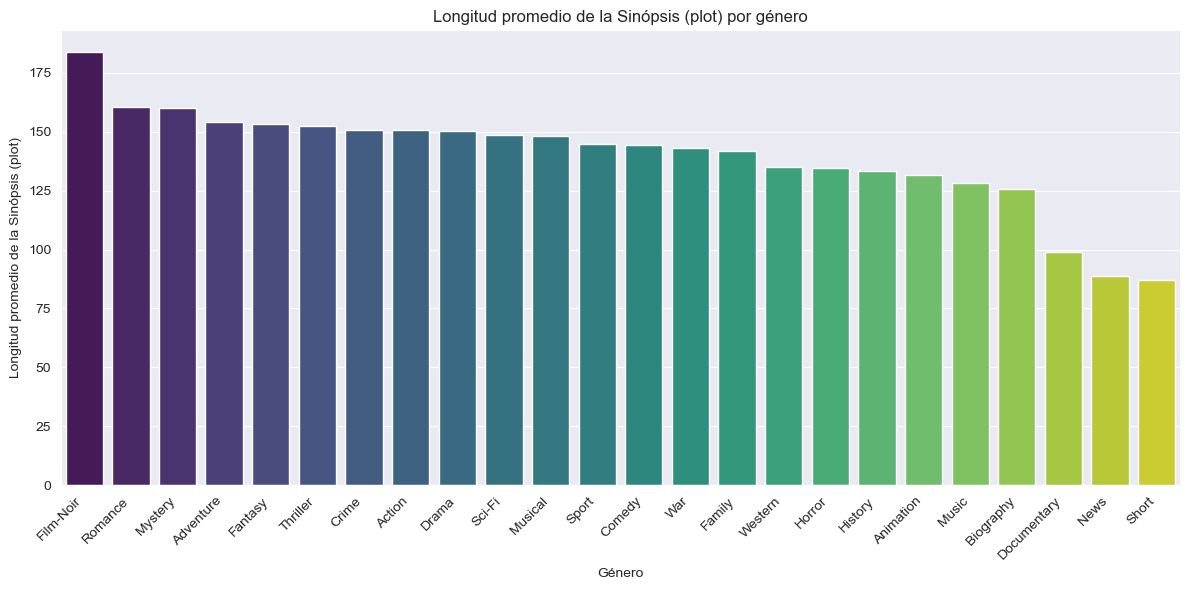

In [ ]:
longitud_plot_genero = pd.DataFrame(dataTraining.explode('genres').groupby('genres')['plot_length'].mean()).sort_values(by='plot_length', ascending=False)
longitud_plot_genero.columns = ['plot_length_mean']

plt.figure(figsize = (12, 6))
sns.barplot(data = longitud_plot_genero, x = longitud_plot_genero.index, y = 'plot_length_mean', palette = 'viridis')
plt.xticks(rotation = 45, ha = 'right')
plt.title('Longitud promedio de la Sinópsis (plot) por género')
plt.xlabel('Género')
plt.ylabel('Longitud promedio de la Sinópsis (plot)')
plt.tight_layout()
plt.show()

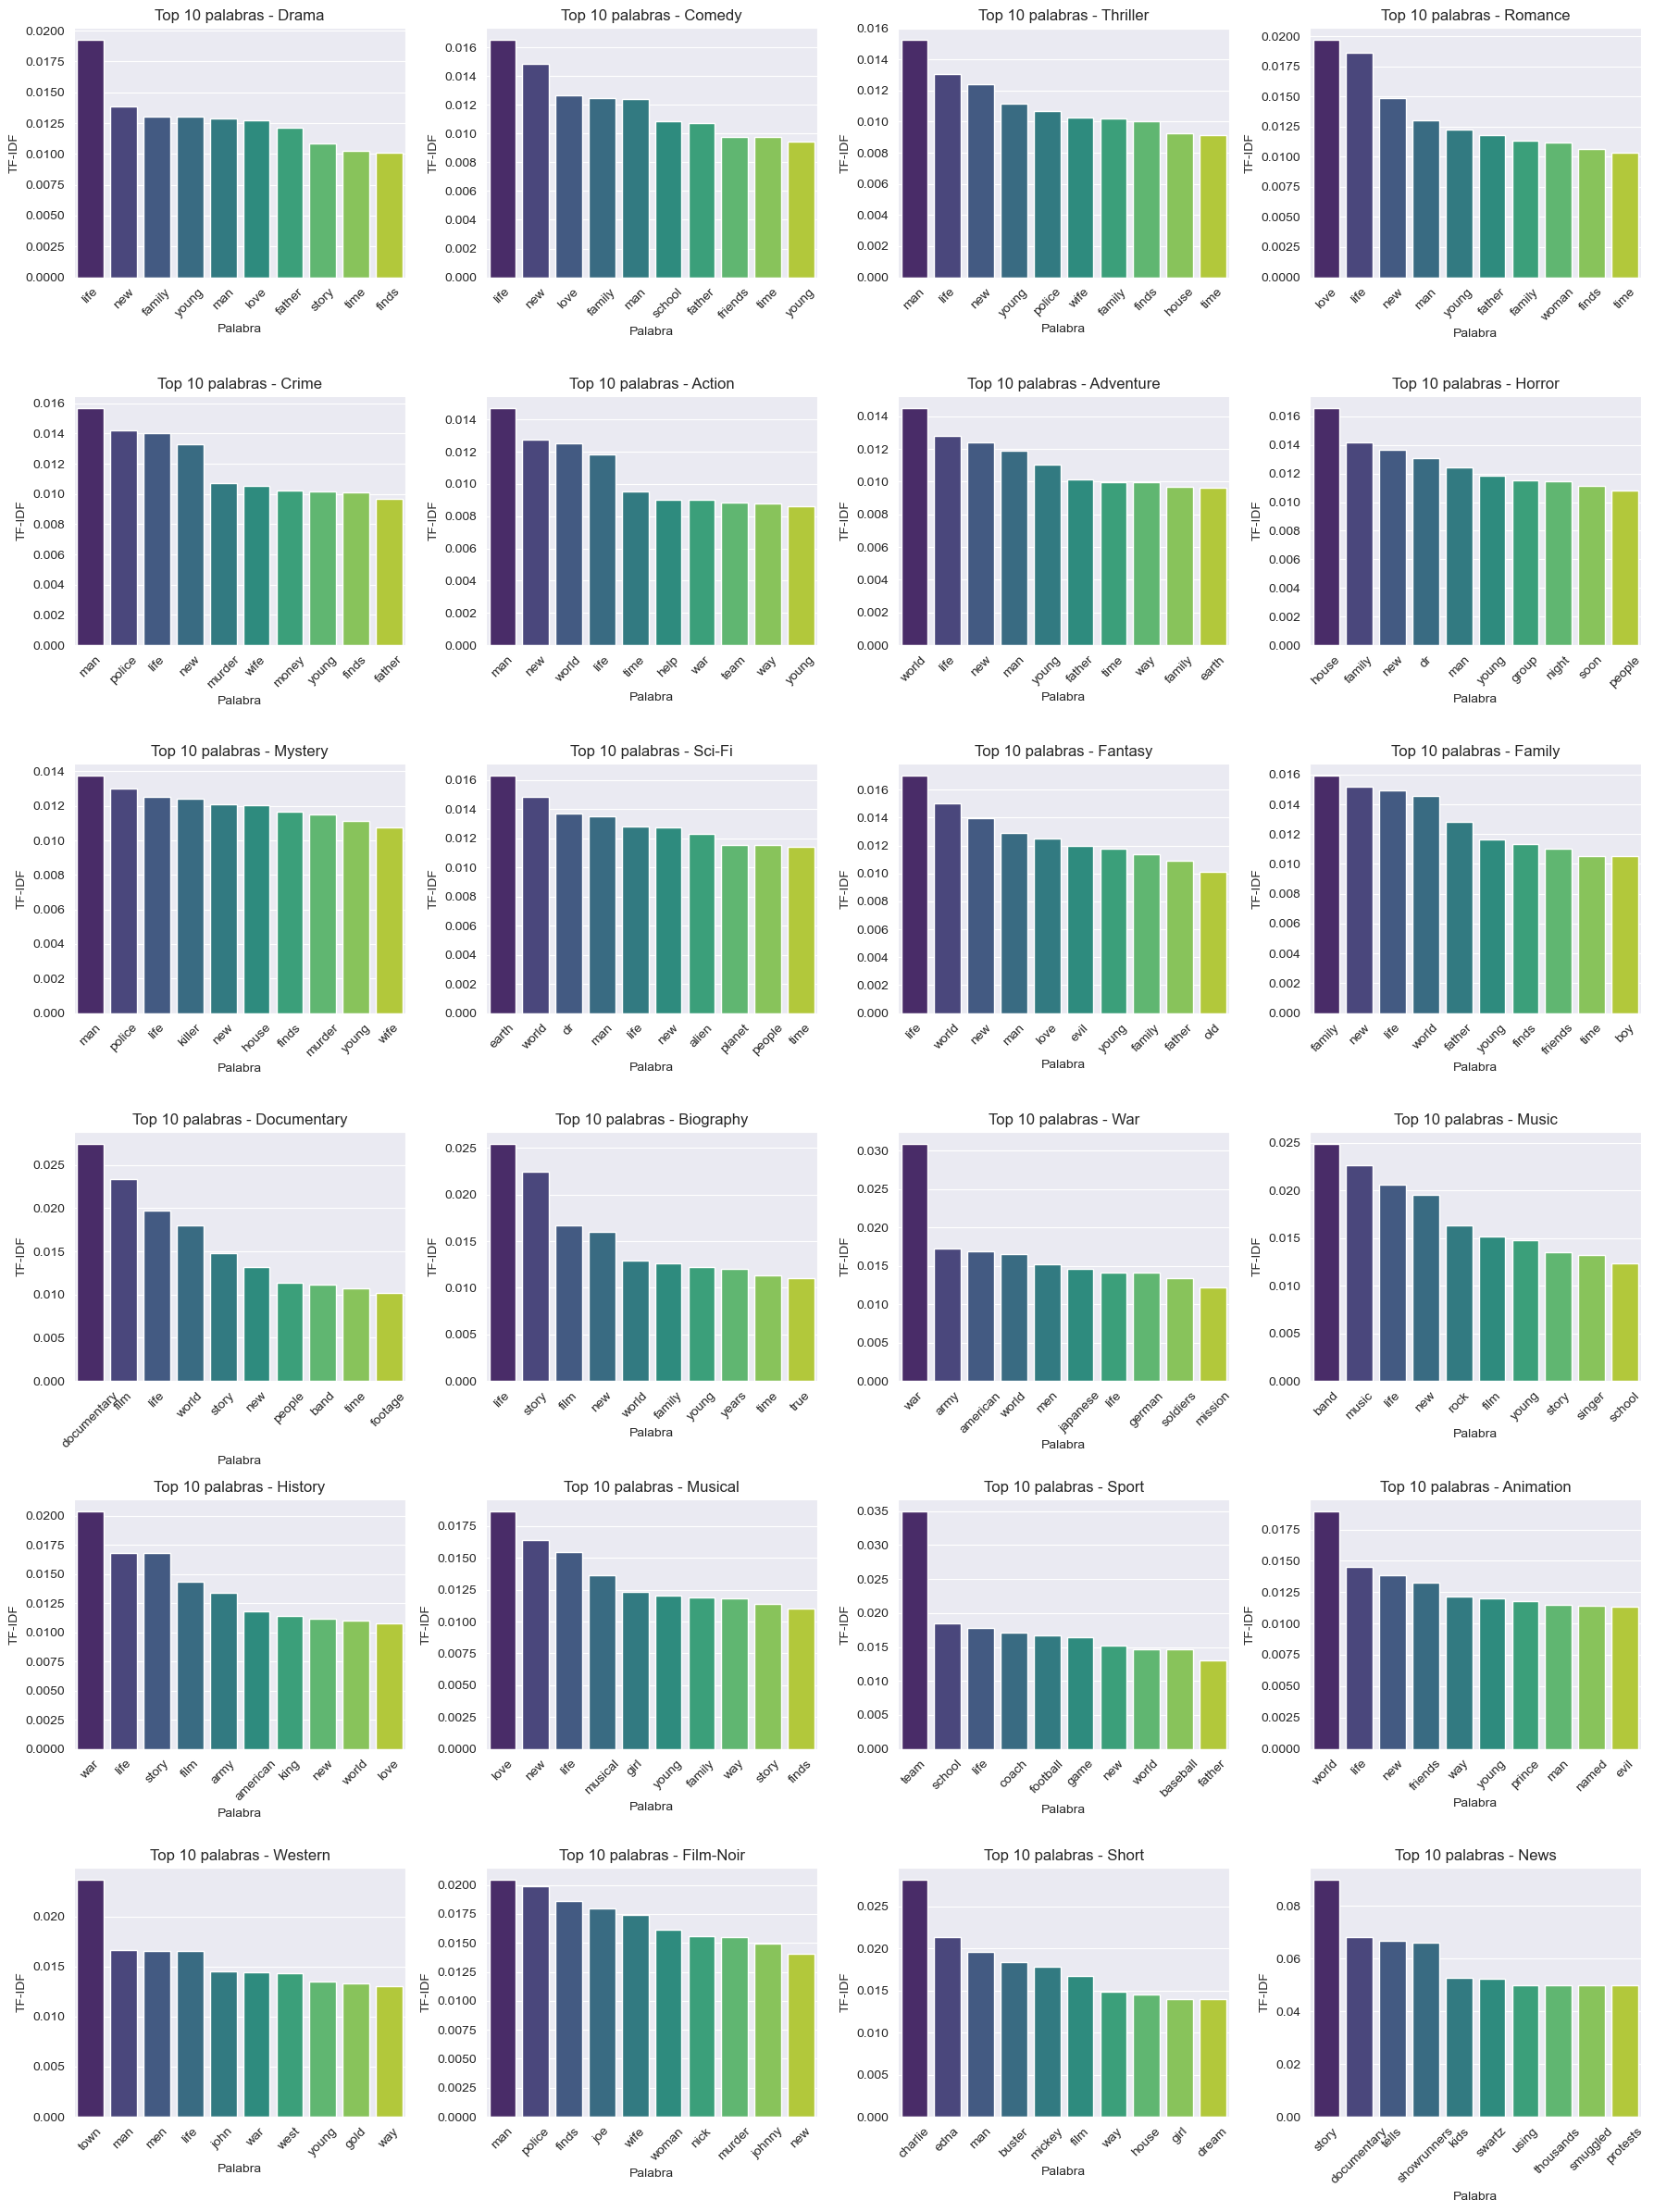

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

fig, axes = plt.subplots(nrows=6, ncols=4, figsize=(18, 24))
axes = axes.flatten()

for idx, i in enumerate(generos.index):
    df_genero = dataTraining[dataTraining['genres'].apply(lambda x: i in x)]
    vectorizer_tfidf = TfidfVectorizer(max_features=10000, stop_words='english')
    df_genero_tfidf = vectorizer_tfidf.fit_transform(df_genero['plot'])
    promedios = df_genero_tfidf.mean(axis=0).A1
    palabras = vectorizer_tfidf.get_feature_names_out()
    top_10_palabras = sorted(zip(promedios, palabras), reverse=True)[:10]
    
    ax = axes[idx]
    sns.barplot(x=[palabra for _, palabra in top_10_palabras],
                y=[promedio for promedio, _ in top_10_palabras],
                palette='viridis', ax=ax) 
    ax.set_title(f'Top 10 palabras - {i}')
    ax.set_xlabel('Palabra')
    ax.set_ylabel('TF-IDF')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

